# Customer Churrn Prediction & Risk Segmentation Dashboard

## Objective
The goal of this project is to predict customer churn using machine learning techniques and segment customers into different risk categories bassed on churn probability.

### Dataset
Telco Customer Churn Dataset

### Technologies used
-Python
-Pandas
-Numpy
-Matplotlib
-Seaborn
-Scikit-learn
-XGBoost

In [3]:
#importing required libraries
import pandas as pd
import numpy as np

#Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

#Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## Loading the Dataset
The dataset is loaded usig Pandas to begin exploitary data analysi and preprocessing.

In [4]:
#Load Dataset
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Display first 10 rows
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## Understanding Dataset tructure
This step helps understand:
-number of rows and columns
-column names
-data types

In [5]:
#Dataset Shape
print("Shape:",df.shape)

#Column Data types
print("\nData Types:\n",df.dtypes)


Shape: (7043, 21)

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## Churn Distribution
This step checks the number of customers who churned and those who stayed
Understanding class distribution is important before training machine learning models.

In [6]:
#Churn distribution
print("Churn Distribution:\n")
print(df['Churn'].value_counts())

Churn Distribution:

Churn
No     5174
Yes    1869
Name: count, dtype: int64


## Checking Missing Values
Missing values can affect machine learning model performance.
This step identifies null or missing values in the dataset.

In [7]:
#Checking missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Converting TotalCharges to Numeric
The TotalCharges column is stored as object type because it contains blank string values.
The column is converted to numeric format using 'pd.to_numeric()'.
Invalid values are converted into NaN using 'errors='coerce''

In [8]:
#Convert TotalCharges to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

#Check missing values again
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## Handling Missing Values
After conversion, a small number of missing values are identified in the TotalCharges column.
Since the missing rows represent less than 1% of the dataset, they were removed using 'dropna()'.

In [9]:
#Remove missing rows
df.dropna(inplace=True)

#Verify missing values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Summary Statistics
Summary statistics help us understand the distribution of numerical features in the dataset such as average values, spread, and range.
This helps identify patterns, unusual values, and overall customer behaviour.

In [10]:
#Summary statistics for numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Observations
-The dataset contains a wide range of customer tenures.

-MontlyCharges vary significantly across customers, indicating different subscription plans.

-TotalCharges has high variation because long-tenure customers accumulate larger bills over time.

-The summary statistics help understand customer spending behaviour before building machine learning models

## Correlation Heatmap
A correlation heatmap is used to visualize the relationship between numerical features in the dataset.

Correlation values range from -1 to +1.
This analysis helps identify how numerical variables such as tenure, MonthlyCharges, and TotalCharges are related to each other

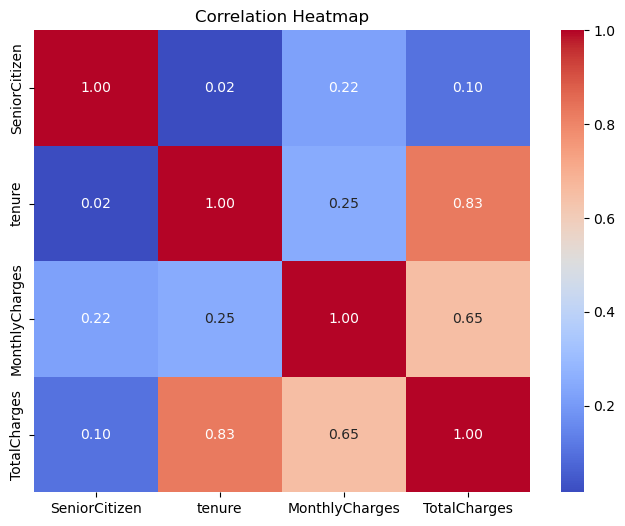

In [11]:
#Selecting only numerical columns
numeric_df=df.select_dtypes(include=['int64','float64'])

#Calculating correlation matrix
correlation_matrix=numeric_df.corr()

#Setting figure size
plt.figure(figsize=(8,6))

#Plotting heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

#Adding title
plt.title("Correlation Heatmap")

#Save Chart
plt.savefig("charts/correlation_heatmap.png")

#Displaying plot
plt.show()

### Observations
-TotalCharges shows positive correlation with tenure because long-term customers accumulate lager total bills over time.

-MonthlyCharges and TotalCharges also have positive correlation.

-No extremely strong negative correlations are observed among numerical features.

-Correlation analysis helps understand relationships between customer billing behaviour and service duration.

# TASK 2 - Data Preprocessing & Feature Engineering.
##Converting TotalCharges to Numeric.

The 'TotalCharges' column was loaded as an object datatype because it contains blank spaces or invalid values.

Machine learning models require numerical values, so we convert it into float format.

We use- 'pd.to_numeric()' to convert text into numbers. 'errors='coerce'' to convert invalid values into NaN.

In [12]:
#Convert TotalCharges to numeric
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")

#Check datatype again
print(df["TotalCharges"].dtype)

float64


## Handling Mising Values

After converting 'TotalCharges' to numeric, some invalid values become NaN.

Since only 11 row are misising out of 7043 rows, we remove them using 'dropna()'.

This avoid introducing incorrect values through imputation.

In [13]:
#Checking missing values again
print(df.isnull().sum())

#Remove rows with missing values
df.dropna(inplace=True)

#Verify removal
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Encoding Categorical Columns

Machine learning models cannot work with text values directly.

We use Label Encoding to convert categorical value into numbers.

for example:

-Yes=1

-No=0

-Female=0

-Male=1



In [14]:
from sklearn.preprocessing import LabelEncoder

#Create encoder object
le=LabelEncoder()

#Encode all object datatype columns
for column in df.columns:
    if df[column].dtype=="object":
        df[column]=le.fit_transform(df[column])

#Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


## Feature Engineering

Feature engineering helps improve model performance by creating meaningful new columns from existing data.

New Features Created:

1.ChargesPerMonth

2.SeniorWithNoSupport

In [15]:
#Create ChargesPerMonth feature
df['ChargesPerMonth']=df['TotalCharges']/(df['tenure']+1)

#Create SeniorWithNoSupport feature
df['SeniorWithNoSupport']=(
    (df['SeniorCitizen']==1)&
    (df['TechSupport']==0)
).astype(int)

#Display new columns
df[['ChargesPerMonth','SeniorWithNoSupport']].head()

,ChargesPerMonth,SeniorWithNoSupport
0,14.925000,0
1,53.985714,0
2,36.050000,0
3,40.016304,0
4,50.550000,0


## Feature Scaling
Feature scaling standardizes numerical values so all features are on similar scale.

We use 'StandardScalar':

-Mean becomes 0

-Standard deviation becomes 1

In [16]:
from sklearn.preprocessing import StandardScaler

#Create scaler object
scaler=StandardScaler()

#Numerical columns to scale
num_cols=['tenure','MonthlyCharges','TotalCharges','ChargesPerMonth']

#Apply scaling
df[num_cols]=scaler.fit_transform(df[num_cols])

#Display first rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChargesPerMonth,SeniorWithNoSupport
0,5365,0,0,1,0,-1.280248,0,1,0,0,...,0,0,0,1,2,-1.161694,-0.994194,0,-1.447223,0
1,3953,1,0,0,0,0.064303,1,0,0,2,...,0,0,1,0,3,-0.260878,-0.173740,0,-0.167059,0
2,2558,1,0,0,0,-1.239504,1,0,0,2,...,0,0,0,1,3,-0.363923,-0.959649,1,-0.754879,0
3,5524,1,0,0,0,0.512486,0,1,0,2,...,0,0,1,0,0,-0.747850,-0.195248,0,-0.624888,0
4,6500,0,0,0,0,-1.239504,1,0,1,0,...,0,0,0,1,2,0.196178,-0.940457,1,-0.279660,0


## Train-Test Split

We split the dataset into:

-80% training data

-20% testing data

'stratify=y' preserves the churn class distribution in both sets.

In [17]:
from sklearn.model_selection import train_test_split

#Features
X=df.drop('Churn',axis=1)

#Target
y=df['Churn']

#Split dataset
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Display shapes
print('X_train shape:',X_train.shape)
print('X_test shape:',X_test.shape)
print('y_train shape:',y_train.shape)
print('y_test shape:',y_test.shape)

X_train shape: (5625, 22)
X_test shape: (1407, 22)
y_train shape: (5625,)
y_test shape: (1407,)


# TASK 3 - Model Training & Comparision

In this task, we train multiple machine learming models to predict customer churn.

Models used:

1.Logistic Regression

2.Random forest classifier

3.Gradient Boosting classifier

We evaluate the models using:

-Accuracy

-Precision

-Recall

-F1-Score

-ROC-AUC Score

we also visualize confusion matrix and ROC Curve

Finally we perform hyperparameter tuning on the best model

## import Machine Learning Models and Evaluation Metrics

We import classification models and performance metrics required for training and evaluation

In [18]:
#Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

#Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model 1 - Logistic Regression

Logistic Regression is a simple and interpretable classification aalgorithm commonly used for binary classification tasks.

In [19]:
#Create Logistic Regression model
lr_model=LogisticRegression(
    max_iter=5000,
    solver='liblinear'
)

#Train model
lr_model.fit(X_train,y_train)

#Predictions
lr_pred=lr_model.predict(X_test)

#Prediction probabilities
lr_prob=lr_model.predict_proba(X_test)[:,1]

## Model 2 - Random Forest Classifier

Random forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [20]:
#Create Random Forest model
rf_model=RandomForestClassifier(random_state=42)

#Train model
rf_model.fit(X_train,y_train)

#Predictions
rf_pred=rf_model.predict(X_test)

#Prediction probabilities
rf_prob=rf_model.predict_proba(X_test)[:,1]

## Model 3 - Gradient Boosting Classifier

Gradient Boosting improves model performance sequentially by correcting previous model errors.

In [21]:
#Create Gradient Boosting model
gb_model=GradientBoostingClassifier(random_state=42)

#Train model
gb_model.fit(X_train,y_train)

#Predictions
gb_pred=gb_model.predict(X_test)

#Prediction probabilities
gb_prob=gb_model.predict_proba(X_test)[:,1]

# Model Evaluation

We evaluate all models using multiple performance metrics.

In [22]:
#Create function for evaluation
def evaluate_model(y_test,predictions,probabilities,model_name):
    print(f"\n----{model_name}----")

    accuracy=accuracy_score(y_test,predictions)
    precision=precision_score(y_test,predictions)
    recall=recall_score(y_test,predictions)
    f1=f1_score(y_test,predictions)
    roc_auc=roc_auc_score(y_test,probabilities)

    print("Accuracy:",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1 Score:",f1)
    print("ROC-AUC:",roc_auc)

#Evaluation models
evaluate_model(y_test,lr_pred,lr_prob,"Logistic Regression")
evaluate_model(y_test,rf_pred,rf_prob,"Random Forest")
evaluate_model(y_test,gb_pred,gb_prob,"Gradient Boosting")


----Logistic Regression----
Accuracy: 0.7917555081734187
Precision: 0.622356495468278
Recall: 0.5508021390374331
F1 Score: 0.5843971631205673
ROC-AUC: 0.8305102732811861

----Random Forest----
Accuracy: 0.7967306325515281
Precision: 0.6456953642384106
Recall: 0.5213903743315508
F1 Score: 0.5769230769230769
ROC-AUC: 0.8216890734116403

----Gradient Boosting----
Accuracy: 0.7974413646055437
Precision: 0.6440129449838188
Recall: 0.5320855614973262
F1 Score: 0.582723279648609
ROC-AUC: 0.8377253832096951


# Confusion Matrix Visualization

Confusion Matrix helps visualize correct and incorrect predictions.

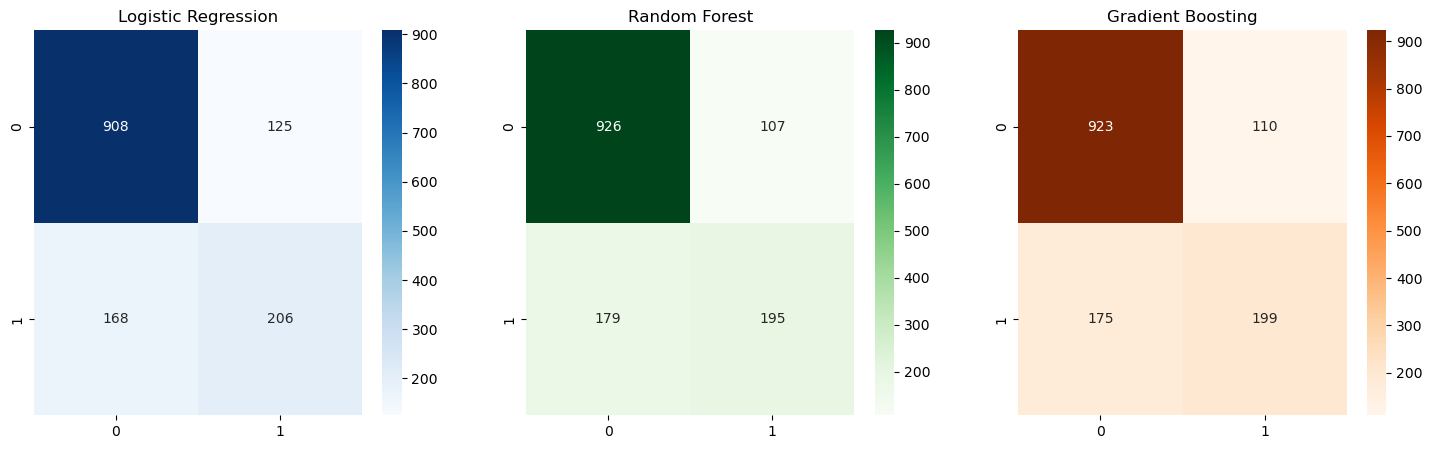

In [23]:
#Create figure
fig,axes=plt.subplots(1,3,figsize=(18,5))

#Logistic Regression
sns.heatmap(confusion_matrix(y_test,lr_pred),
            annot=True,
            fmt='d',
            ax=axes[0],
            cmap='Blues')
axes[0].set_title("Logistic Regression")

#Random Forest
sns.heatmap(confusion_matrix(y_test,rf_pred),
            annot=True,
            fmt='d',
            ax=axes[1],
            cmap='Greens')
axes[1].set_title("Random Forest")

#Gradient Boosting
sns.heatmap(confusion_matrix(y_test,gb_pred),
            annot=True,
            fmt='d',
            ax=axes[2],
            cmap='Oranges')
axes[2].set_title("Gradient Boosting")

#Save chart
plt.savefig("charts/confusion_matrix.png",bbox_inches='tight')

plt.show()

## ROC Curve Comparision

ROC Curve compares model performance across different probability thresholds.

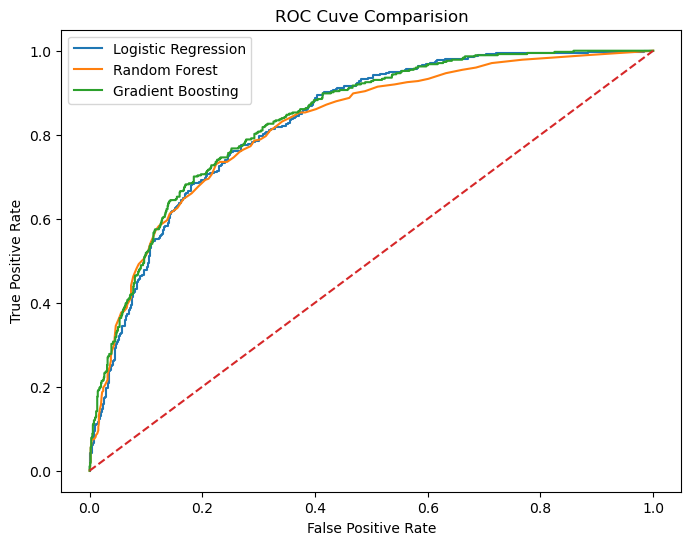

In [42]:
#Calculate ROC values
lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob)
rf_fpr,rf_tpr,_=roc_curve(y_test,rf_prob)
gb_fpr,gb_tpr,_=roc_curve(y_test,gb_prob)

#Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(lr_fpr,lr_tpr,label='Logistic Regression')
plt.plot(rf_fpr,rf_tpr,label='Random Forest')
plt.plot(gb_fpr,gb_tpr,label='Gradient Boosting')

#Diagonal line
plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Cuve Comparision")

plt.legend()

#Save fig
plt.savefig("model_comparision.png",bbox_inches='tight')

plt.show()

## Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning improves model performance by testing multiple parameter combinations.

In [25]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [26]:
from sklearn.model_selection import GridSearchCV

#Parameter grid
param_grid={
    'n_estimators':[50,100],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}

#GridSearch
grid_search=GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy'
)


In [27]:
#Train grid search
grid_search.fit(X_train,y_train)

#Best parameters
print(grid_search.best_params_)
#Best score
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
0.8008888888888889


# TASK 3 SUMMARY

In this task:

-Trained 3 machine learning classification models

-Compared model performance

-Evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC

-Visualized Confusion matrix and ROC Curve

-Performed hyperparameter tuning using GridSearchCV

The best performing model will be used for customer risk segmentation in Task 4

# TASK 4-Customer Risk Segmentation[ADVANCED]

In this task, we use the best-performing machine learning model to predict customer churn possibilities.

## Selecting Best Performing Model
Gradient Boosting acheived the best overall ROC-AUC performance and is selected for cutomer risk segmentation.

In [28]:
#Predicted probabilities from best model
best_model_prob=gb_model.predict_proba(X_test)[:,1]

#Create dataframe for analysis
risk_df=X_test.copy()

#Add actual churn values
risk_df["ActualChurn"]=y_test.values

#Add churn probability
risk_df["ChurnProbability"]=best_model_prob

#Display first rows
risk_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport,ActualChurn,ChurnProbability
974,407,0,0,1,1,1.082902,1,0,0,0,...,2,2,1,1,0.370691,0.996664,0.544790,0,0,0.030438
619,2838,0,0,0,0,-1.035784,1,2,1,0,...,0,0,1,0,0.457116,-0.776645,0.206005,0,0,0.615222
4289,1516,0,0,0,0,0.879182,1,0,2,1,...,1,2,0,3,-1.485788,-0.531124,-1.293142,0,0,0.016964
3721,1957,0,0,0,0,-1.239504,1,0,2,1,...,1,0,0,3,-1.467506,-0.990290,-1.513590,0,1,0.121845
4533,3802,0,0,1,0,1.571829,1,2,1,0,...,2,2,1,0,1.341311,2.325808,1.502592,0,0,0.138937


## Customer Customer Risk Tiers

Customers are segmented based on churn probability scores.

In [29]:
#Function to assign risk tier
def assign_risk(prob):
    if prob>=0.70:
        return "High Risk"
    elif prob>=0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

#Apply risk segmentation
risk_df["RiskTier"]=risk_df["ChurnProbability"].apply(assign_risk)

#Display first rows
risk_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,ChargesPerMonth,SeniorWithNoSupport,ActualChurn,ChurnProbability,RiskTier
974,407,0,0,1,1,1.082902,1,0,0,0,...,2,1,1,0.370691,0.996664,0.544790,0,0,0.030438,Low Risk
619,2838,0,0,0,0,-1.035784,1,2,1,0,...,0,1,0,0.457116,-0.776645,0.206005,0,0,0.615222,Medium Risk
4289,1516,0,0,0,0,0.879182,1,0,2,1,...,2,0,3,-1.485788,-0.531124,-1.293142,0,0,0.016964,Low Risk
3721,1957,0,0,0,0,-1.239504,1,0,2,1,...,0,0,3,-1.467506,-0.990290,-1.513590,0,1,0.121845,Low Risk
4533,3802,0,0,1,0,1.571829,1,2,1,0,...,2,1,0,1.341311,2.325808,1.502592,0,0,0.138937,Low Risk


## Customer Count by Risk Tier

In [30]:
#Count customers in each risk tier

risk_counts=risk_df["RiskTier"].value_counts()
print(risk_counts)

RiskTier
Low Risk       986
Medium Risk    296
High Risk      125
Name: count, dtype: int64


## Average MonthlyCharges and Tenure by Risk Tier


In [31]:
#Average values by risk tier
risk_summary=risk_df.groupby("RiskTier")[[
    "MonthlyCharges",
    "tenure"
]].mean()

print(risk_summary)

             MonthlyCharges    tenure
RiskTier                             
High Risk          0.453273 -1.166817
Low Risk          -0.176356  0.325709
Medium Risk        0.269004 -0.701023


## Contract Type Distribution by Risk Tier

In [32]:
#Contract related columns
contract_columns=[
    col for col in risk_df.columns
    if "Contract" in col
]

#Group by risk tier
contract_distribution=risk_df.groupby("RiskTier")[
    contract_columns
    ].mean()

print(contract_distribution)


             Contract
RiskTier             
High Risk    0.000000
Low Risk     0.953347
Medium Risk  0.013514


## Grouped Bar Chart Comparison

The grouped bar chart compares customer risk tiers across:

-Average Monthly Charges

-Average Tenure


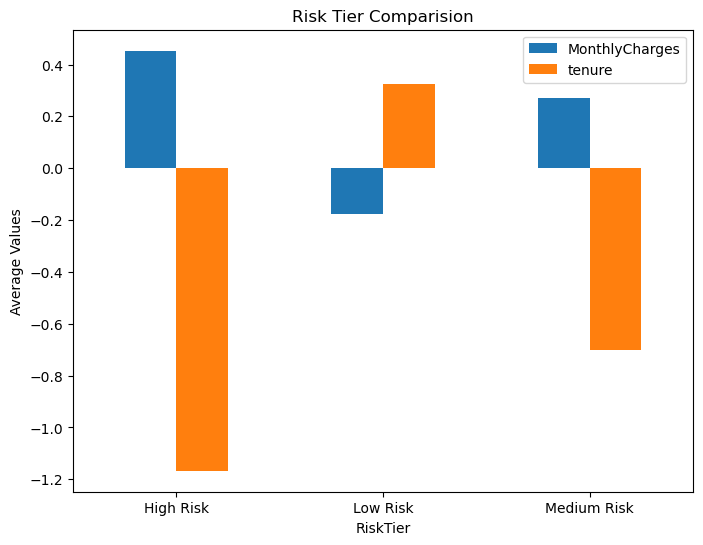

In [33]:
#Reset index for plotting
plot_data=risk_summary.reset_index()

#Create grouped bar chart
plot_data.plot(
    x="RiskTier",
    kind="bar",
    figsize=(8,6)
)

#Labels and title
plt.title("Risk Tier Comparision")
plt.ylabel("Average Values")
plt.xticks(rotation=0)

#Save fig
plt.savefig("charts/risk_tier_comparision.png",bbox_inches='tight')

plt.show()

## Risk Segmentation Insights

Observations:

-High-risk customers generally have shorter tenure periods.

-Customers with higher monthly charges are more likely to churn.

-Month-to-month contract customers appear more frequently in the high-risk segment.

-Low-risk customers are typically long-term customers with stable service subscriptions.


# TASK 5 -Visualizations

In this task, we create multiple visualizations to better understand customer churn behavior and model insights.

Charts Created:

1.Feature Importance Bar Chart

2.Churn rate by contract type

3.Tenure distribution-Churned vs Non-Churned

4.Risk Tier Pie Chart

5.Bonus:Interactive Scatter Plot using Plotly

## Chart 1-Feature Importance

Feature importance helps identify which variables contribute most to churn prediction.

In [34]:
#Get feature importance values
importance=rf_model.feature_importances_

#Create dataframe
feature_importance_df=pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":importance
})

#Sort values 
feature_importance_df=feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

#Select top 10 features
top_10_features=feature_importance_df.head(10)

#Display dataframe
print(top_10_features)

            Feature  Importance
19     TotalCharges    0.131155
5            tenure    0.124204
18   MonthlyCharges    0.122318
20  ChargesPerMonth    0.117981
0        customerID    0.108729
15         Contract    0.074361
9    OnlineSecurity    0.040832
17    PaymentMethod    0.037240
12      TechSupport    0.034986
10     OnlineBackup    0.025787


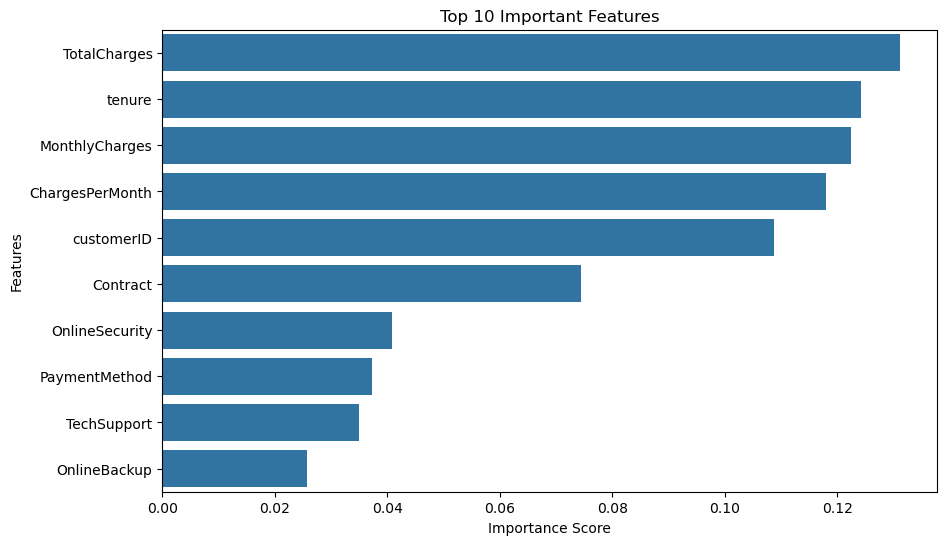

In [35]:
#Plot feature importance

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

#Save chart
plt.savefig("charts/top_10_important_features.png",bbox_inches='tight')

plt.show()


### Feature Importance Insights

The chart highlights the most influential features affecting customer churn.

Features such as

-Contract type

-MonthlyCharges

-Tenure

typically have strong influence on churn behavior.

## Chart 2- Churn Rate by Contract Type

This chart compares churn behavior across different contract types.

In [36]:
#Create temporary dataframe

contract_df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#Churn rate by contract

contract_churn=pd.crosstab(
    contract_df["Contract"],
    contract_df["Churn"],
    normalize='index'
)

#Display values

print(contract_churn)

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


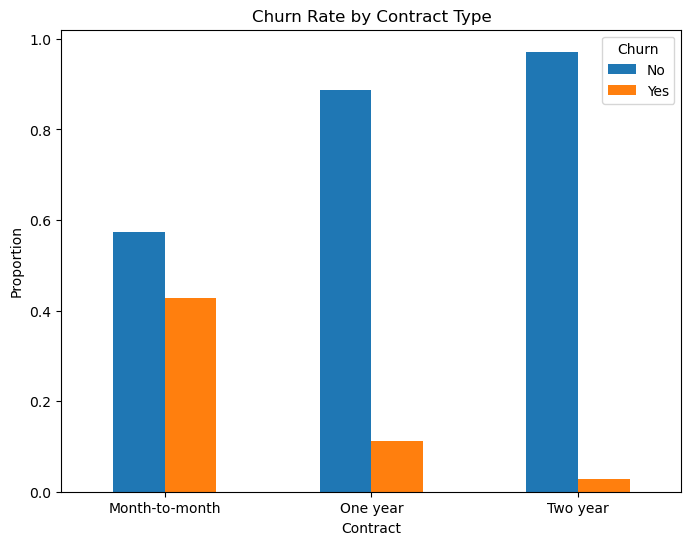

In [37]:
#Plot churn rate by contract

contract_churn.plot(
    kind='bar',
    figsize=(8,6)
)
plt.title("Churn Rate by Contract Type")

plt.ylabel("Proportion")

plt.xticks(rotation=0)

#Save fig
plt.savefig("charts/churn_rate_by_contract_type.png",bbox_inches='tight')

plt.show()

### Contract Type Insights

Customers with Month-to-Month contracts tend to churn more frequently compared to One-Year and Two-Year contract customers.

Long-term contracts are associated with better customer retention.

# Chart 3 - Tenure Distribution by Churn Status

This visualization compares customer tenure distribution between churned and non-churned customers.

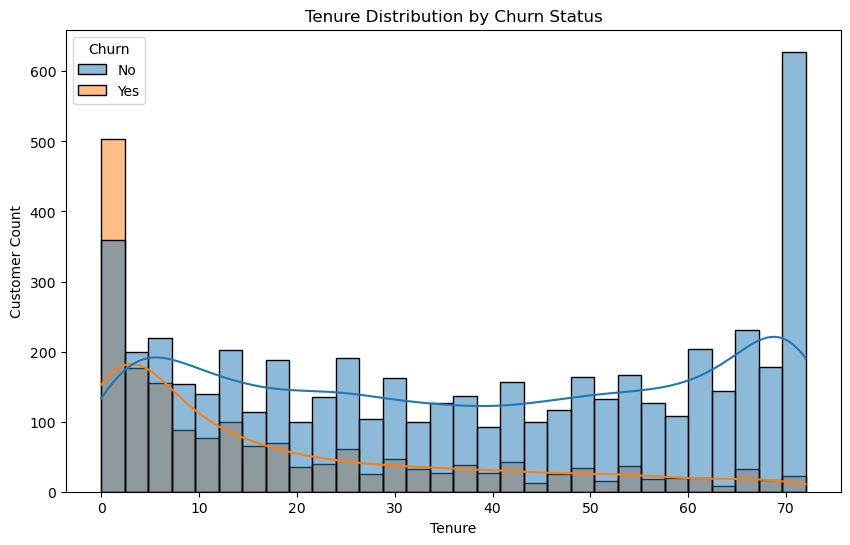

In [38]:
#Load original dataset again

tenure_df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

#plot histogram

plt.figure(figsize=(10,6))

sns.histplot(
    data=tenure_df,
    x="tenure",
    hue="Churn",
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Tenure")
plt.ylabel("Customer Count")

#Save fig
plt.savefig("charts/tenure_distribution_by_churn_status.png",bbox_inches='tight')
plt.show()

## Chart 4 - Customer Risk Tier Distribution

This chart shows the proportion of customers across different churn risk categories.

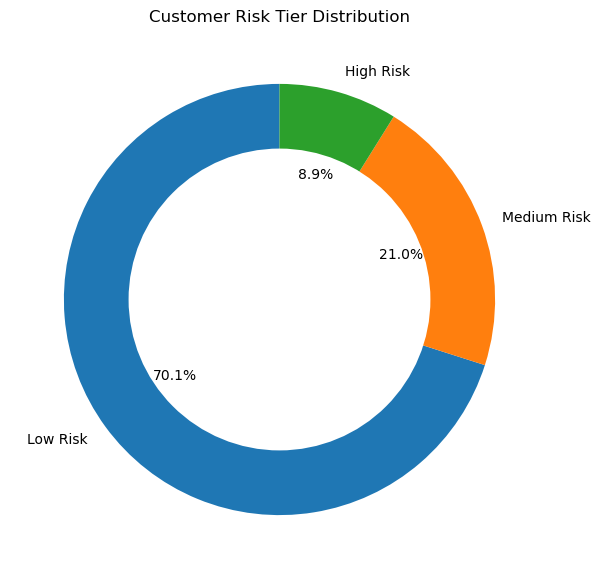

In [39]:
# Risk tier counts

risk_counts = risk_df["RiskTier"].value_counts()

# Plot pie chart

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

# Create donut effect

centre_circle = plt.Circle((0,0), 0.70, fc='white')

fig = plt.gcf()

fig.gca().add_artist(centre_circle)

plt.title("Customer Risk Tier Distribution")

#Save fig
plt.savefig("charts/customer_risk_tier_distribution.png",bbox_inches='tight')

plt.show()

### Risk Tier Insights

The majority of customers fall into the Low Risk category, while a smaller portion belongs to High Risk.

High-risk customers should be prioritized for retention strategies.

## Bonus Chart — Interactive Scatter Plot using Plotly

This interactive chart visualizes the relationship between:
- Monthly Charges
- Tenure
- Churn Status

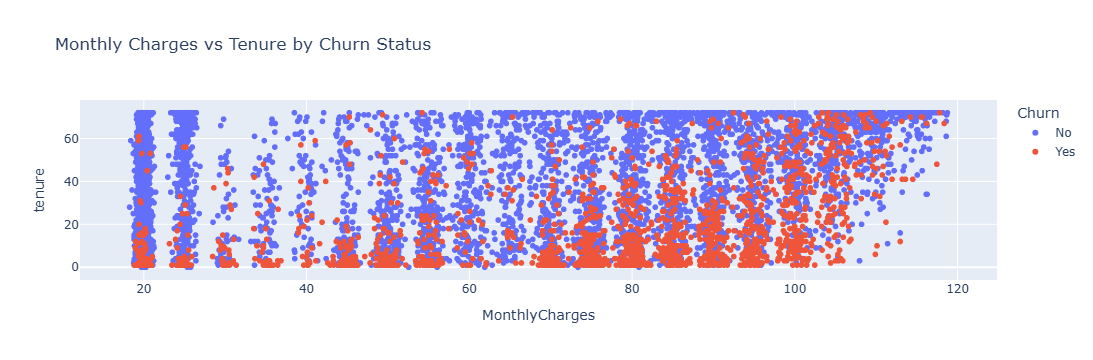

<Figure size 640x480 with 0 Axes>

In [47]:
import plotly.express as px

# Load original dataset

plotly_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Create scatter plot

fig = px.scatter(
    plotly_df,
    x="MonthlyCharges",
    y="tenure",
    color="Churn",
    title="Monthly Charges vs Tenure by Churn Status"
)

#Save fig
plt.savefig("charts/monthly_charges_vs_tenure_by_churn_status.png")

# Show plot

fig.show()


### Scatter Plot Insights

Customers with:
- high monthly charges
- lower tenure

appear more likely to churn.

Interactive visualization helps identify customer behavior patterns more effectively.


# Task 5 Summary

In this task, multiple visualizations were created to analyze:
- feature importance
- churn behavior
- customer tenure patterns
- contract type impact
- customer risk segmentation

These visualizations improve interpretability and provide actionable business insights for churn reduction strategies.

# TASK 6 – Insights & Business Recommendations

## Best Performing Model
Gradient Boosting was selected as the best-performing model with the highest ROC-AUC score of **0.8377**. The model performs well because it improves prediction accuracy iteratively by correcting errors from previous trees, making it highly effective for churn prediction tasks.

## Top 3 Factors Driving Customer Churn
The three most influential features identified by the model were:
1. **TotalCharges (0.131)**
2. **Tenure (0.124)**
3. **MonthlyCharges (0.122)**

These results indicate that billing amount and customer longevity are the strongest indicators of customer churn.

## High Risk Customer Characteristics
High-risk customers are mostly associated with:
- **Month-to-Month contracts**
- **Higher MonthlyCharges**
- **Lower tenure values**

This suggests that newly joined customers paying higher charges without long-term commitment are more likely to churn.

## Business Recommendations
### Recommendation 1
Offer discounted contract upgrades or loyalty incentives to Month-to-Month customers within their first 6 months. The analysis showed that churn drops significantly from approximately **43%** for Month-to-Month customers to around **11%** for One-Year contract customers.

### Recommendation 2
Deploy the Gradient Boosting model in production to identify customers with churn probability greater than **0.70** and proactively target them with retention strategies such as personalized offers, discounts, or service credits.

## Model Limitations
The model achieved a Recall score of approximately **0.53**, meaning some actual churn customers are still not detected. In addition, class imbalance, limited behavioral data, and lack of customer satisfaction metrics may restrict model performance.

## Future Improvements
Future enhancements could include:
- Applying **SMOTE** or other balancing techniques
- Adding features such as support call history and competitor pricing
- Incorporating customer feedback data
- Periodically retraining the model using updated datasets